In [1]:
import importlib, subprocess, sys
REQUIRED = {
    'diffusers': 'diffusers==0.31.0',
    'transformers': 'transformers==4.46.3',
    'accelerate': 'accelerate==1.0.1',
    'peft': 'peft==0.13.2',
    'bitsandbytes': 'bitsandbytes',
    'safetensors': 'safetensors',
    'huggingface_hub': 'huggingface-hub',
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

In [2]:
import os, json, glob, shutil, time, random, math, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

PyTorch: 2.4.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 7.6 GB


In [3]:
LAB = Path(os.getcwd()).resolve()
if LAB.name != 'lab-8':
    cand = LAB / 'lab-8'
    if cand.exists():
        LAB = cand.resolve()
DATA = LAB / 'data'
ME_DIR = DATA / 'me'
CLASS_DIR = DATA / 'class_men'
LORA_DIR = LAB / 'runs' / 'lora_sd15_v3'
SAMPLES_DIR = LAB / 'samples'
RESULTS_PATH = LAB / 'results.json'

for p in [DATA, CLASS_DIR, LORA_DIR, SAMPLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

BASE_MODEL = 'runwayml/stable-diffusion-v1-5'
INSTANCE_TOKEN = 'ohwx'
CLASS_NOUN = 'man'
INSTANCE_PROMPT = f'a photo of {INSTANCE_TOKEN} {CLASS_NOUN}'
CLASS_PROMPT = f'a photo of a {CLASS_NOUN}'

RESOLUTION = 512
LORA_RANK = 32
LR_UNET = 1e-4
LR_TEXT = 5e-5
MAX_TRAIN_STEPS = 8000
SAVE_EVERY = 2000
GRAD_ACCUM = 1
BATCH = 1
NUM_CLASS_IMAGES = 200
PRIOR_LOSS_WEIGHT = 1.0

INFERENCE_STEPS = 40
GUIDANCE = 7.0
LORA_SCALE = 0.7
SEED = 42

print('LAB:', LAB)
print('device:', device)
print('instance prompt:', INSTANCE_PROMPT)
print('class prompt:', CLASS_PROMPT)

LAB: /mnt/data/itmo-cv/lab-8
device: cuda
instance prompt: a photo of ohwx man
class prompt: a photo of a man


## 1. Референсные фото

20 reference photos in /mnt/data/itmo-cv/lab-8/data/me


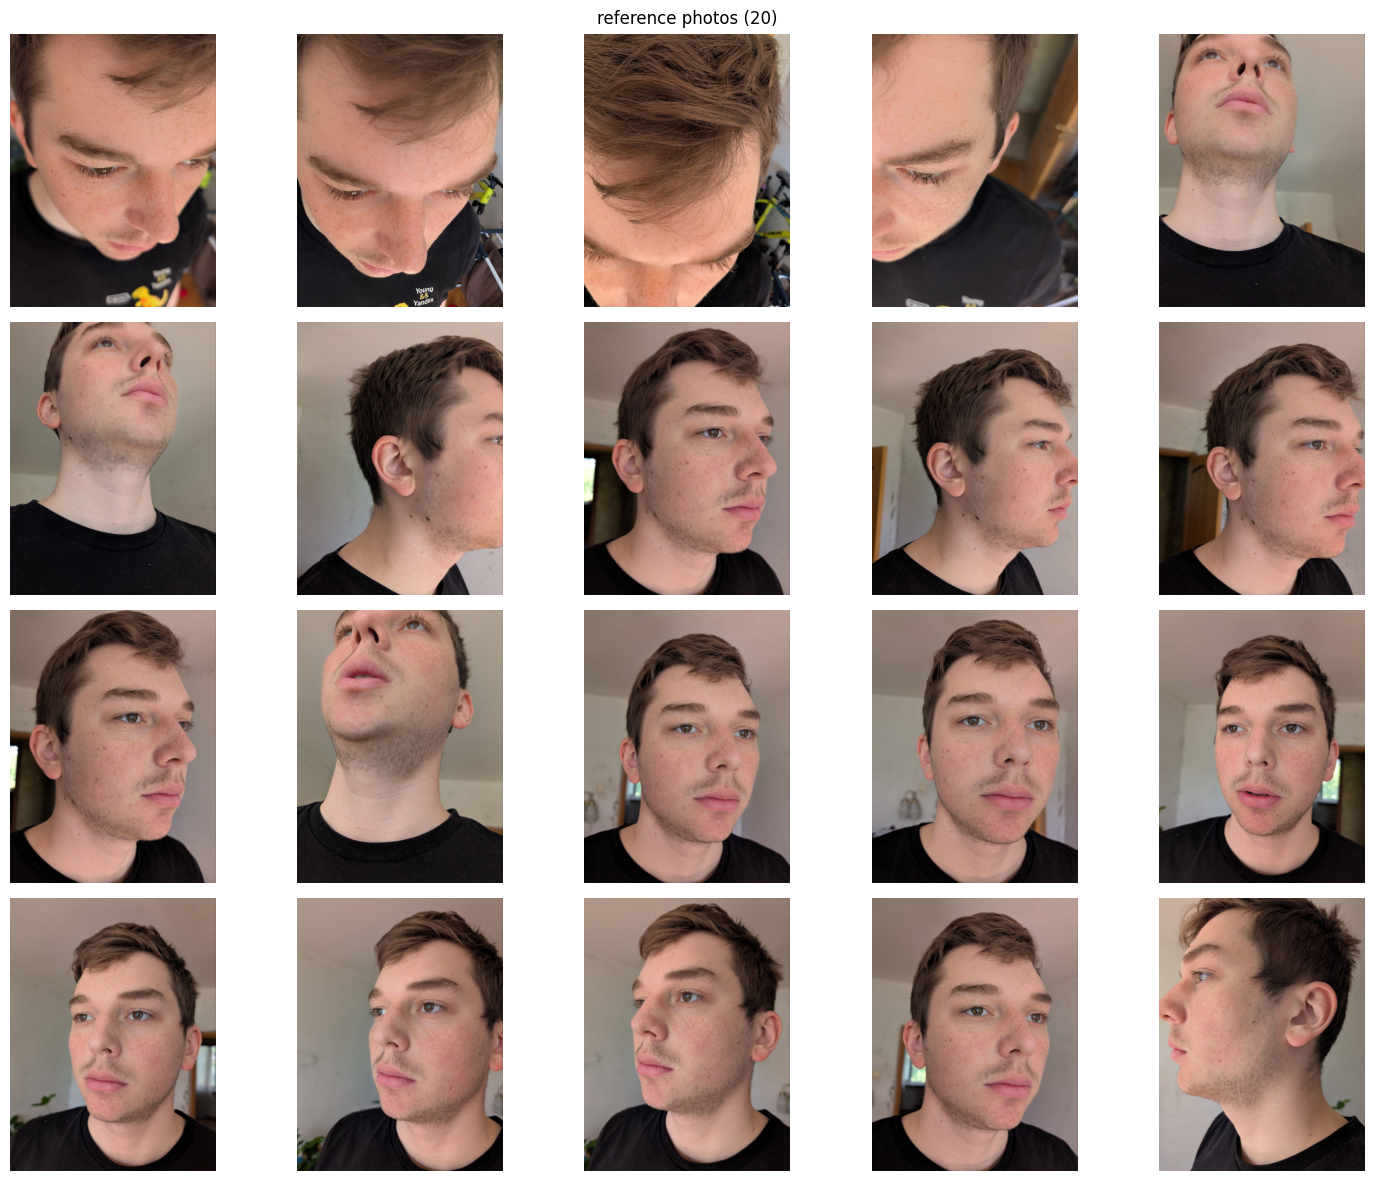

In [4]:
exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
me_imgs = sorted(sum([list(ME_DIR.glob(e)) for e in exts], []))
print(f'{len(me_imgs)} reference photos in {ME_DIR}')
if len(me_imgs) < 5:
    raise SystemExit(f'нужно минимум 5 фото в {ME_DIR}')

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, p in zip(axes.flat, me_imgs[:20]):
    ax.imshow(Image.open(p).convert('RGB'))
    ax.axis('off')
for ax in axes.flat[len(me_imgs):]:
    ax.axis('off')
plt.suptitle(f'reference photos ({len(me_imgs)})')
plt.tight_layout(); plt.show()

## 2. Class images для prior preservation

[skip] 200 class images already generated
class images: 200


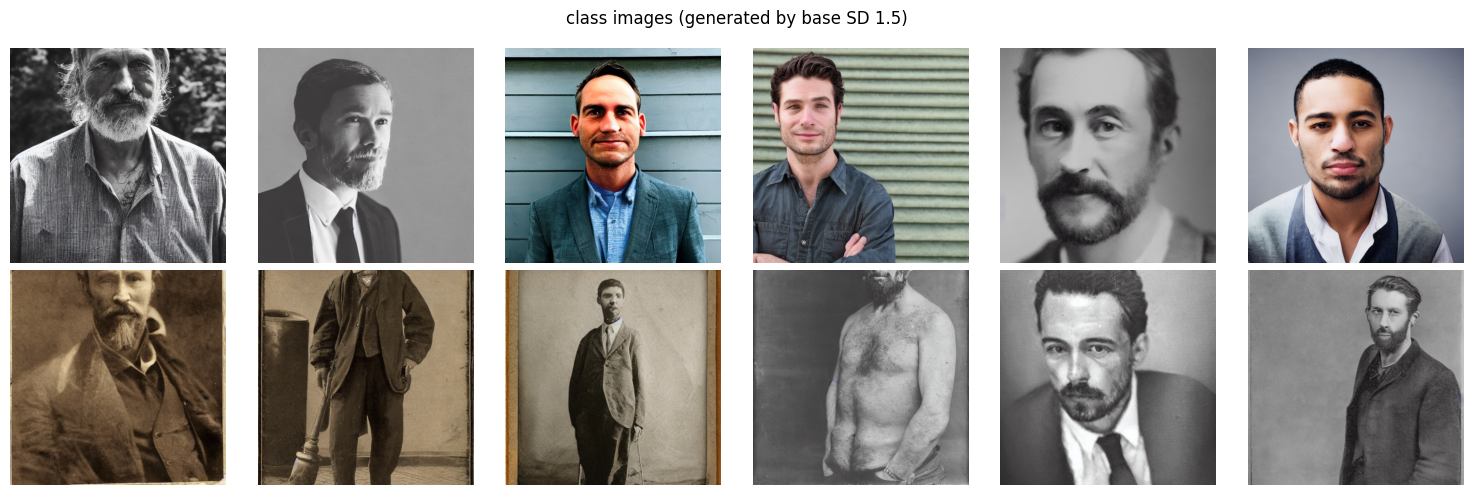

In [5]:
from diffusers import StableDiffusionPipeline

existing_class = sorted(CLASS_DIR.glob('*.png'))
if len(existing_class) >= NUM_CLASS_IMAGES:
    print(f'[skip] {len(existing_class)} class images already generated')
else:
    print(f'generating {NUM_CLASS_IMAGES} class images with base SD 1.5...')
    gen_pipe = StableDiffusionPipeline.from_pretrained(BASE_MODEL, torch_dtype=torch.float16,
                                                       safety_checker=None, requires_safety_checker=False)
    gen_pipe = gen_pipe.to(device)
    gen_pipe.set_progress_bar_config(disable=True)
    g = torch.Generator(device=device).manual_seed(123)
    t0 = time.time()
    for i in tqdm(range(len(existing_class), NUM_CLASS_IMAGES), desc='class gen'):
        img = gen_pipe(CLASS_PROMPT, num_inference_steps=25, guidance_scale=7.5, generator=g).images[0]
        img.save(CLASS_DIR / f'class_{i:04d}.png')
    print(f'generated in {(time.time()-t0)/60:.1f} min')
    del gen_pipe
    torch.cuda.empty_cache()

class_imgs = sorted(CLASS_DIR.glob('*.png'))
print(f'class images: {len(class_imgs)}')

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for ax, p in zip(axes.flat, class_imgs[:12]):
    ax.imshow(Image.open(p).convert('RGB'))
    ax.axis('off')
plt.suptitle('class images (generated by base SD 1.5)')
plt.tight_layout(); plt.show()

## 3. Dataset с DreamBooth prior preservation

In [6]:
from transformers import CLIPTokenizer
tokenizer = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder='tokenizer')

INSTANCE_VARIANTS = [
    f'a photo of {INSTANCE_TOKEN} {CLASS_NOUN}',
    f'a portrait of {INSTANCE_TOKEN} {CLASS_NOUN}',
    f'a photo of {INSTANCE_TOKEN} {CLASS_NOUN}, looking at camera',
    f'photo of {INSTANCE_TOKEN} {CLASS_NOUN}',
]
CLASS_VARIANTS = [
    f'a photo of a {CLASS_NOUN}',
    f'a portrait of a {CLASS_NOUN}',
    f'photo of a {CLASS_NOUN}',
    f'a {CLASS_NOUN}',
]


class DreamBoothDataset(Dataset):
    def __init__(self, instance_paths, class_paths, tokenizer, resolution=512):
        self.instance_paths = list(instance_paths)
        self.class_paths = list(class_paths)
        self.tokenizer = tokenizer
        self.tf = transforms.Compose([
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(resolution),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
    def _tok(self, prompt):
        return self.tokenizer(prompt, padding='max_length', max_length=self.tokenizer.model_max_length,
                              truncation=True, return_tensors='pt').input_ids[0]
    def __len__(self):
        return max(len(self.instance_paths), len(self.class_paths)) * 100
    def __getitem__(self, i):
        inst_p = self.instance_paths[i % len(self.instance_paths)]
        cls_p = self.class_paths[i % len(self.class_paths)]
        inst_img = self.tf(Image.open(inst_p).convert('RGB'))
        cls_img = self.tf(Image.open(cls_p).convert('RGB'))
        inst_prompt = INSTANCE_VARIANTS[i % len(INSTANCE_VARIANTS)]
        cls_prompt = CLASS_VARIANTS[i % len(CLASS_VARIANTS)]
        return {
            'instance_pixel_values': inst_img,
            'class_pixel_values': cls_img,
            'instance_input_ids': self._tok(inst_prompt),
            'class_input_ids': self._tok(cls_prompt),
        }


train_ds = DreamBoothDataset(me_imgs, class_imgs, tokenizer, RESOLUTION)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
print('dataset:', len(train_ds), 'samples (with repeat)')

dataset: 20000 samples (with repeat)


## 4. SD 1.5 + LoRA (UNet + text encoder)

In [7]:
from diffusers import DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel
from peft import LoraConfig, get_peft_model
import bitsandbytes as bnb

text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder='text_encoder', torch_dtype=torch.float32).to(device)
vae = AutoencoderKL.from_pretrained(BASE_MODEL, subfolder='vae', torch_dtype=torch.float16).to(device)
unet = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder='unet', torch_dtype=torch.float32).to(device)
noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder='scheduler')

for p in vae.parameters(): p.requires_grad_(False)
for p in unet.parameters(): p.requires_grad_(False)
for p in text_encoder.parameters(): p.requires_grad_(False)

unet.enable_gradient_checkpointing()
text_encoder.gradient_checkpointing_enable()

unet_lora = LoraConfig(r=LORA_RANK, lora_alpha=LORA_RANK,
                       target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
                       lora_dropout=0.0, bias='none')
text_lora = LoraConfig(r=LORA_RANK, lora_alpha=LORA_RANK,
                       target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj'],
                       lora_dropout=0.0, bias='none')
unet = get_peft_model(unet, unet_lora)
text_encoder = get_peft_model(text_encoder, text_lora)
unet.print_trainable_parameters()
text_encoder.print_trainable_parameters()

trainable params: 6,377,472 || all params: 865,898,436 || trainable%: 0.7365
trainable params: 2,359,296 || all params: 125,419,776 || trainable%: 1.8811


## 5. Тренировка DreamBooth LoRA с prior preservation

In [8]:
unet_final = LORA_DIR / 'unet_lora.safetensors'
text_final = LORA_DIR / 'text_lora.safetensors'
history_path = LORA_DIR / 'history.csv'

from safetensors.torch import save_file

def save_lora(step_tag=''):
    unet_sd = {k: v.detach().cpu().contiguous() for k, v in unet.state_dict().items() if 'lora_' in k}
    text_sd = {k: v.detach().cpu().contiguous() for k, v in text_encoder.state_dict().items() if 'lora_' in k}
    save_file(unet_sd, str(LORA_DIR / f'unet_lora{step_tag}.safetensors'))
    save_file(text_sd, str(LORA_DIR / f'text_lora{step_tag}.safetensors'))

if unet_final.exists() and text_final.exists():
    print(f'[skip] LoRA already trained: {unet_final}')
    history = pd.read_csv(history_path).values.tolist() if history_path.exists() else []
else:
    optimizer = bnb.optim.AdamW8bit([
        {'params': [p for p in unet.parameters() if p.requires_grad], 'lr': LR_UNET},
        {'params': [p for p in text_encoder.parameters() if p.requires_grad], 'lr': LR_TEXT},
    ], betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8)

    def forward_loss(pixel_values, input_ids):
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
        encoder_hidden_states = text_encoder(input_ids)[0]
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.size(0),), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            model_pred = unet(noisy_latents.float(), timesteps, encoder_hidden_states.float()).sample
            return F.mse_loss(model_pred.float(), noise.float())

    history = []
    step = 0
    t0 = time.time()
    pbar = tqdm(total=MAX_TRAIN_STEPS, desc='lora train')
    acc_inst, acc_cls = 0.0, 0.0
    while step < MAX_TRAIN_STEPS:
        for batch in train_loader:
            inst_pv = batch['instance_pixel_values'].to(device, dtype=torch.float16)
            cls_pv = batch['class_pixel_values'].to(device, dtype=torch.float16)
            inst_ids = batch['instance_input_ids'].to(device)
            cls_ids = batch['class_input_ids'].to(device)
            if inst_ids.dim() == 1: inst_ids = inst_ids.unsqueeze(0)
            if cls_ids.dim() == 1: cls_ids = cls_ids.unsqueeze(0)

            loss_inst = forward_loss(inst_pv, inst_ids)
            loss_inst.backward()
            loss_cls = forward_loss(cls_pv, cls_ids) * PRIOR_LOSS_WEIGHT
            loss_cls.backward()

            optimizer.step()
            optimizer.zero_grad()

            acc_inst += loss_inst.item()
            acc_cls += loss_cls.item() / PRIOR_LOSS_WEIGHT

            step += 1
            if step % 25 == 0:
                history.append([step, acc_inst / 25, acc_cls / 25])
                pbar.set_postfix(inst=f'{acc_inst/25:.4f}', cls=f'{acc_cls/25:.4f}')
                acc_inst = acc_cls = 0.0
            pbar.update(1)
            if step % SAVE_EVERY == 0:
                save_lora(f'_step_{step}')
                pd.DataFrame(history, columns=['step', 'loss_inst', 'loss_cls']).to_csv(history_path, index=False)
            if step >= MAX_TRAIN_STEPS:
                break
    pbar.close()

    save_lora('')
    pd.DataFrame(history, columns=['step', 'loss_inst', 'loss_cls']).to_csv(history_path, index=False)
    print(f'LoRA trained in {(time.time()-t0)/60:.1f} min')


[skip] LoRA already trained: /mnt/data/itmo-cv/lab-8/runs/lora_sd15_v3/unet_lora.safetensors


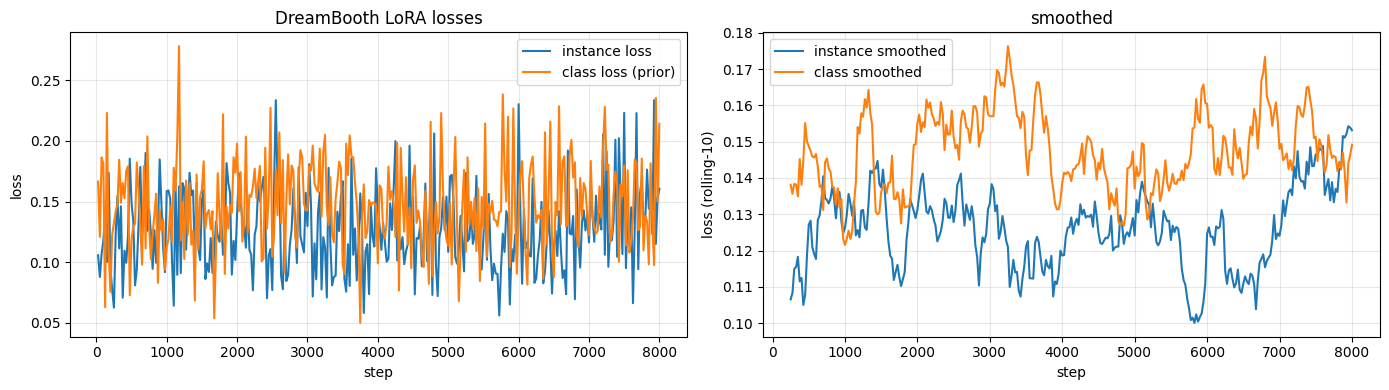

In [9]:
if Path(history_path).exists():
    df = pd.read_csv(history_path)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df['step'], df['loss_inst'], color='tab:blue', label='instance loss')
    axes[0].plot(df['step'], df['loss_cls'], color='tab:orange', label='class loss (prior)')
    axes[0].set_xlabel('step'); axes[0].set_ylabel('loss'); axes[0].set_title('DreamBooth LoRA losses')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(df['step'], df['loss_inst'].rolling(10).mean(), color='tab:blue', label='instance smoothed')
    axes[1].plot(df['step'], df['loss_cls'].rolling(10).mean(), color='tab:orange', label='class smoothed')
    axes[1].set_xlabel('step'); axes[1].set_ylabel('loss (rolling-10)'); axes[1].set_title('smoothed')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 6. Сборка пайплайна, LoRA scale = 0.7

In [10]:
del unet, text_encoder, vae
torch.cuda.empty_cache()

pipe = StableDiffusionPipeline.from_pretrained(BASE_MODEL, torch_dtype=torch.float16,
                                                safety_checker=None, requires_safety_checker=False)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=True)

from peft import LoraConfig as PeftLoraConfig
from safetensors.torch import load_file

u_cfg = PeftLoraConfig(r=LORA_RANK, lora_alpha=int(LORA_RANK * LORA_SCALE),
                       target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
                       lora_dropout=0.0, bias='none')
t_cfg = PeftLoraConfig(r=LORA_RANK, lora_alpha=int(LORA_RANK * LORA_SCALE),
                       target_modules=['q_proj', 'k_proj', 'v_proj', 'out_proj'],
                       lora_dropout=0.0, bias='none')
pipe.unet = get_peft_model(pipe.unet, u_cfg)
pipe.text_encoder = get_peft_model(pipe.text_encoder, t_cfg)
u_sd = load_file(str(unet_final))
t_sd = load_file(str(text_final))
pipe.unet.load_state_dict(u_sd, strict=False)
pipe.text_encoder.load_state_dict(t_sd, strict=False)
pipe.unet = pipe.unet.to(device, dtype=torch.float16).eval()
pipe.text_encoder = pipe.text_encoder.to(device, dtype=torch.float16).eval()
print(f'pipeline ready, lora_scale={LORA_SCALE}')

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

pipeline ready, lora_scale=0.7


## 7. Генерация: 6 стилей

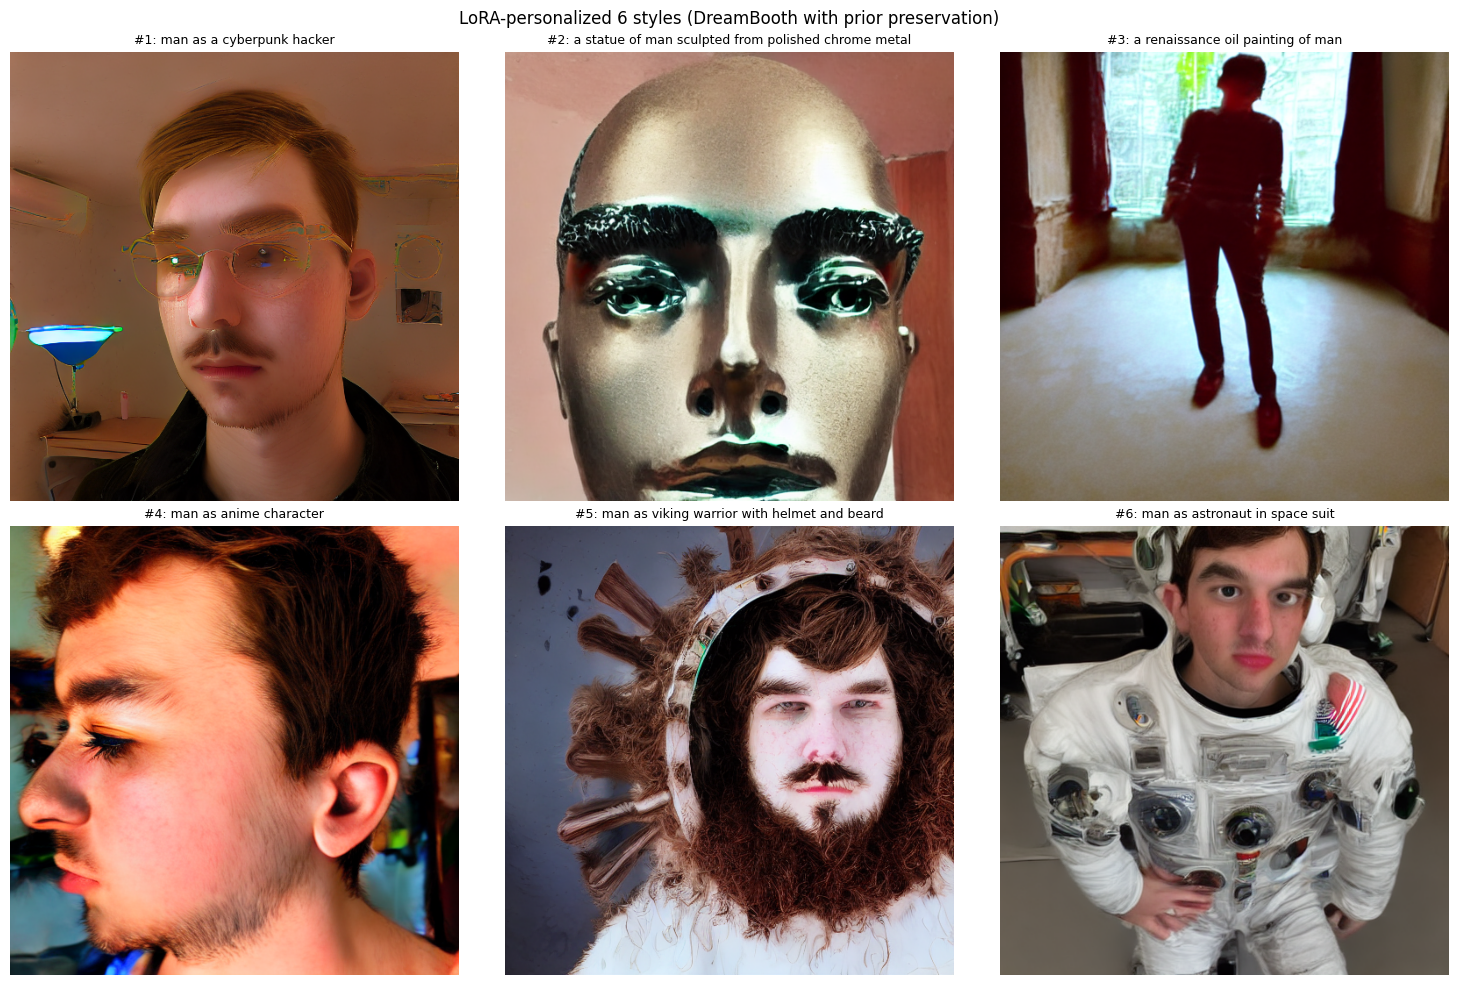

In [11]:
STYLE_PROMPTS = [
    f'{INSTANCE_TOKEN} {CLASS_NOUN} as a cyberpunk hacker, neon lights, futuristic city, glowing reflections, cinematic',
    f'a statue of {INSTANCE_TOKEN} {CLASS_NOUN} sculpted from polished chrome metal, reflective surface, studio',
    f'a renaissance oil painting of {INSTANCE_TOKEN} {CLASS_NOUN}, baroque background, dramatic lighting',
    f'{INSTANCE_TOKEN} {CLASS_NOUN} as anime character, studio ghibli style, vibrant colors',
    f'{INSTANCE_TOKEN} {CLASS_NOUN} as viking warrior with helmet and beard, snowy mountain, fur cloak, epic fantasy',
    f'{INSTANCE_TOKEN} {CLASS_NOUN} as astronaut in space suit, helmet, on the moon, earth in background',
]

style_results = []
g = torch.Generator(device=device).manual_seed(SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, prompt in enumerate(STYLE_PROMPTS):
    out = pipe(prompt, num_inference_steps=INFERENCE_STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    out_path = SAMPLES_DIR / f'style_{i+1:02d}.png'
    out.save(out_path)
    style_results.append({'index': i+1, 'prompt': prompt, 'file': str(out_path)})
    ax = axes[i//3, i%3]
    ax.imshow(out); ax.axis('off')
    short = prompt.split(',')[0].replace(f'{INSTANCE_TOKEN} ', '')
    ax.set_title(f'#{i+1}: {short}', fontsize=9)
plt.suptitle('LoRA-personalized 6 styles (DreamBooth with prior preservation)')
plt.tight_layout(); plt.show()

## 8. Хайлайт

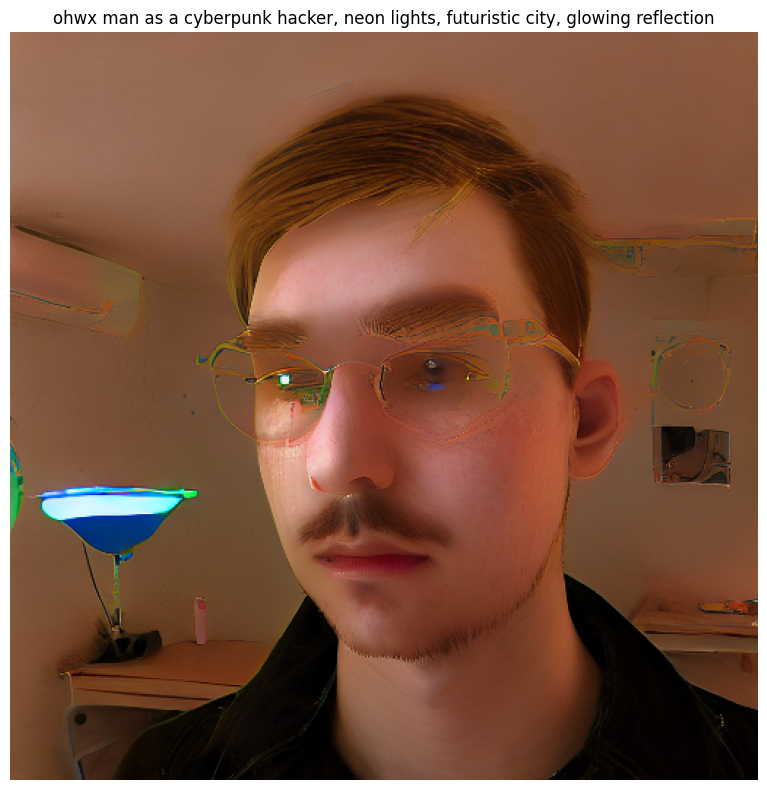

In [12]:
best = Image.open(SAMPLES_DIR / 'style_01.png')
plt.figure(figsize=(8, 8))
plt.imshow(best); plt.axis('off')
plt.title(STYLE_PROMPTS[0][:80])
plt.tight_layout(); plt.show()

## 9. forest / city / beach

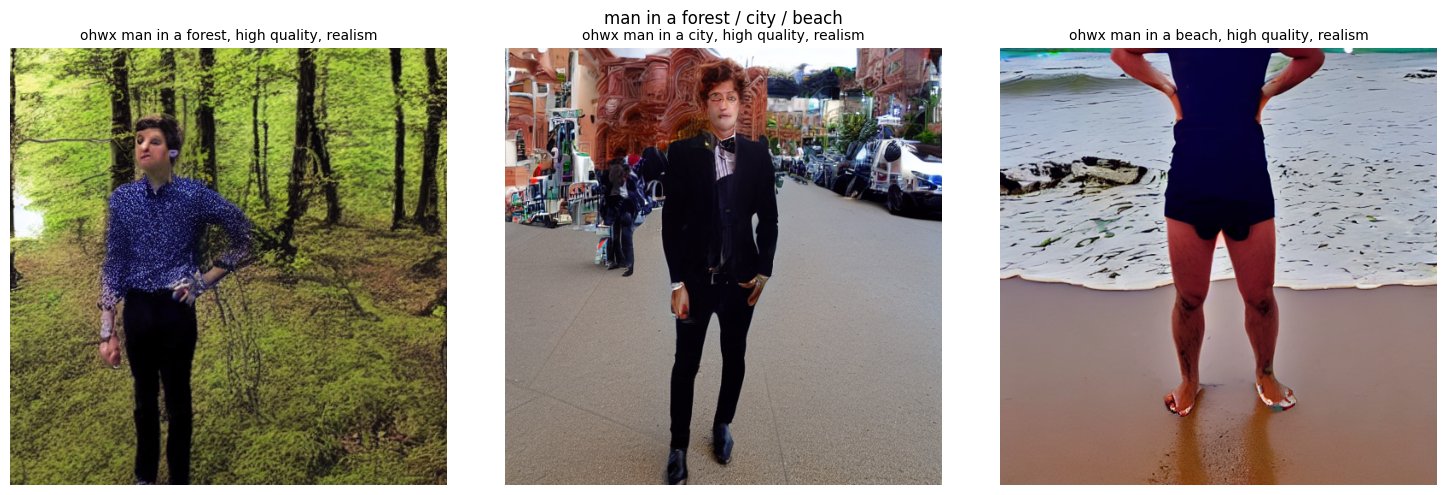

In [13]:
ENV_PROMPTS = [
    f'{INSTANCE_TOKEN} {CLASS_NOUN} in a forest, high quality, realism',
    f'{INSTANCE_TOKEN} {CLASS_NOUN} in a city, high quality, realism',
    f'{INSTANCE_TOKEN} {CLASS_NOUN} in a beach, high quality, realism',
]

env_results = []
g = torch.Generator(device=device).manual_seed(SEED + 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, prompt in enumerate(ENV_PROMPTS):
    out = pipe(prompt, num_inference_steps=INFERENCE_STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    out_path = SAMPLES_DIR / f'env_{i+1:02d}.png'
    out.save(out_path)
    env_results.append({'index': i+1, 'prompt': prompt, 'file': str(out_path)})
    axes[i].imshow(out); axes[i].axis('off')
    axes[i].set_title(prompt, fontsize=10)
plt.suptitle(f'{CLASS_NOUN} in a forest / city / beach')
plt.tight_layout(); plt.show()

## 10. results.json

In [14]:
results = {
    'task': 'personalized_text_to_image_StableDiffusion',
    'base_model': BASE_MODEL,
    'method': 'DreamBooth LoRA with prior preservation (UNet + text encoder LoRA)',
    'instance_token': INSTANCE_TOKEN,
    'class_noun': CLASS_NOUN,
    'instance_prompt': INSTANCE_PROMPT,
    'class_prompt': CLASS_PROMPT,
    'lora': {
        'rank': LORA_RANK,
        'unet_target_modules': ['to_q', 'to_k', 'to_v', 'to_out.0'],
        'text_target_modules': ['q_proj', 'k_proj', 'v_proj', 'out_proj'],
        'optimizer': 'AdamW8bit (bitsandbytes)',
        'lr_unet': LR_UNET,
        'lr_text': LR_TEXT,
        'max_train_steps': MAX_TRAIN_STEPS,
        'save_every': SAVE_EVERY,
        'grad_accum': GRAD_ACCUM,
        'batch_size': BATCH,
        'prior_loss_weight': PRIOR_LOSS_WEIGHT,
        'num_class_images': NUM_CLASS_IMAGES,
    },
    'inference': {
        'resolution': RESOLUTION,
        'num_inference_steps': INFERENCE_STEPS,
        'guidance_scale': GUIDANCE,
        'lora_scale': LORA_SCALE,
        'negative_prompt': None,
        'use_img2img': False,
    },
    'reference_photos': [p.name for p in me_imgs],
    'style_outputs': style_results,
    'env_outputs': env_results,
}
RESULTS_PATH.write_text(json.dumps(results, indent=2, ensure_ascii=False))
print(json.dumps({k: results[k] for k in ['base_model', 'method', 'instance_prompt', 'lora', 'inference']}, indent=2, ensure_ascii=False))

{
  "base_model": "runwayml/stable-diffusion-v1-5",
  "method": "DreamBooth LoRA with prior preservation (UNet + text encoder LoRA)",
  "instance_prompt": "a photo of ohwx man",
  "lora": {
    "rank": 32,
    "unet_target_modules": [
      "to_q",
      "to_k",
      "to_v",
      "to_out.0"
    ],
    "text_target_modules": [
      "q_proj",
      "k_proj",
      "v_proj",
      "out_proj"
    ],
    "optimizer": "AdamW8bit (bitsandbytes)",
    "lr_unet": 0.0001,
    "lr_text": 5e-05,
    "max_train_steps": 8000,
    "save_every": 2000,
    "grad_accum": 1,
    "batch_size": 1,
    "prior_loss_weight": 1.0,
    "num_class_images": 200
  },
  "inference": {
    "resolution": 512,
    "num_inference_steps": 40,
    "guidance_scale": 7.0,
    "lora_scale": 0.7,
    "negative_prompt": null,
    "use_img2img": false
  }
}
